## Pull BigQuery Dataset:

In [17]:
# ============================================================
# Cell 1: Imports, Auth, Config
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.oauth2 import service_account
from google.cloud import bigquery

# ── Styling ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# ── Config ───────────────────────────────────────────────────
PROJECT_ID = "recosys-489001"
DATASET_ID = "recosys"
TABLE_ID   = "events_raw"
TABLE_REF  = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"
KEY_PATH   = os.path.expanduser("C:\\Users\\Patron\\Documents\\GitHub\\RecoSys\\secrets\\recosys-service-account.json")

# ── Auth ─────────────────────────────────────────────────────
credentials = service_account.Credentials.from_service_account_file(
    KEY_PATH,
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
bq = bigquery.Client(project=PROJECT_ID, credentials=credentials)
print(f"✅ Connected — {credentials.service_account_email}")

✅ Connected — 921967012784-compute@developer.gserviceaccount.com


In [18]:
# ============================================================
# Cell 2: Query Helper
# ============================================================
import time

# Simple in-memory cache so re-running cells doesn't re-bill you
_cache = {}

def run_query(sql: str, label: str = "", use_cache: bool = True) -> pd.DataFrame:
    """
    Run a BigQuery SQL query and return a DataFrame.
    
    - Dry-runs first to print bytes that will be scanned.
    - Caches results in memory by label (set use_cache=False to force refresh).
    - Prints elapsed time on completion.
    """
    cache_key = label or sql[:120]
    
    if use_cache and cache_key in _cache:
        df = _cache[cache_key]
        print(f"[cache] '{label}' → {len(df):,} rows")
        return df

    # ── Dry run: estimate cost before executing ──────────────
    dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    dry_job = bq.query(sql, job_config=dry_config)
    bytes_scanned = dry_job.total_bytes_processed
    gb_scanned    = bytes_scanned / 1e9
    cost_est      = (bytes_scanned / 1e12) * 5  # $5 per TB

    print(f"{'─'*60}")
    if label:
        print(f"  Query  : {label}")
    print(f"  Scan   : {gb_scanned:.2f} GB  (~${cost_est:.4f})")
    
    # Warn but don't block — you decide whether to proceed
    if gb_scanned > 10:
        print(f"  ⚠️  Large scan — confirm this is intentional")

    # ── Execute ──────────────────────────────────────────────
    t0  = time.time()
    job = bq.query(sql)
    df  = job.result().to_dataframe()
    elapsed = time.time() - t0

    print(f"  Rows   : {len(df):,}")
    print(f"  Time   : {elapsed:.1f}s")
    print(f"{'─'*60}")

    if label:
        _cache[cache_key] = df
    return df


def clear_cache():
    _cache.clear()
    print("Cache cleared.")

In [19]:
# ============================================================
# Cell 3: Table metadata — zero cost
# ============================================================
table = bq.get_table(TABLE_REF)
print(f"Table      : {table.full_table_id}")
print(f"Rows       : {table.num_rows:,}")
print(f"Size       : {table.num_bytes/1e9:.2f} GB")
print(f"Created    : {table.created}")
print(f"Modified   : {table.modified}")
print(f"\nSchema:")
for f in table.schema:
    nullable = "NULLABLE" if f.is_nullable else "REQUIRED"
    print(f"  {f.name:<20} {f.field_type:<12} {nullable}")

Table      : recosys-489001:recosys.events_raw
Rows       : 288,779,227
Size       : 32.03 GB
Created    : 2026-03-06 02:10:45.210000+00:00
Modified   : 2026-03-06 02:10:45.210000+00:00

Schema:
  event_time           TIMESTAMP    NULLABLE
  event_type           STRING       NULLABLE
  product_id           INTEGER      NULLABLE
  category_id          INTEGER      NULLABLE
  category_code        STRING       NULLABLE
  brand                STRING       NULLABLE
  price                FLOAT        NULLABLE
  user_id              INTEGER      NULLABLE
  user_session         STRING       NULLABLE


## BigQuery EDA

In [20]:
# ============================================================
# AREA 0: Monthly Volume Breakdown
# DETERMINISTIC — no thresholds needed
# PURPOSE: Confirm all 7 months loaded correctly, see growth
#          trends, event mix per month
# ============================================================
sql_area0 = f"""
SELECT
  FORMAT_TIMESTAMP('%Y-%m', event_time)         AS month,
  COUNT(*)                                       AS total_events,
  COUNT(DISTINCT user_id)                        AS unique_users,
  COUNT(DISTINCT product_id)                     AS unique_products,
  COUNTIF(event_type = 'view')                   AS views,
  COUNTIF(event_type = 'cart')                   AS carts,
  COUNTIF(event_type = 'purchase')               AS purchases,
  ROUND(COUNTIF(event_type = 'cart')
        / COUNT(*) * 100, 2)                     AS cart_rate_pct,
  ROUND(COUNTIF(event_type = 'purchase')
        / COUNT(*) * 100, 2)                     AS purchase_rate_pct
FROM `{TABLE_REF}`
GROUP BY month
ORDER BY month
"""
df_area0 = run_query(sql_area0, label="area0_monthly_volume")
df_area0

────────────────────────────────────────────────────────────
  Query  : area0_monthly_volume
  Scan   : 8.68 GB  (~$0.0434)
  Rows   : 5
  Time   : 2.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,month,total_events,unique_users,unique_products,views,carts,purchases,cart_rate_pct,purchase_rate_pct
0,2019-10,42448764,3022290,166794,40779399,926516,742849,2.18,1.75
1,2019-11,67501979,3696117,190662,63556110,3028930,916939,4.49,1.36
2,2019-12,67542878,4577232,205230,62986067,3394763,1162048,5.03,1.72
3,2020-01,55967041,4385985,227608,52490785,2641249,835007,4.72,1.49
4,2020-02,55318565,4233206,258469,51232669,2885608,1200288,5.22,2.17


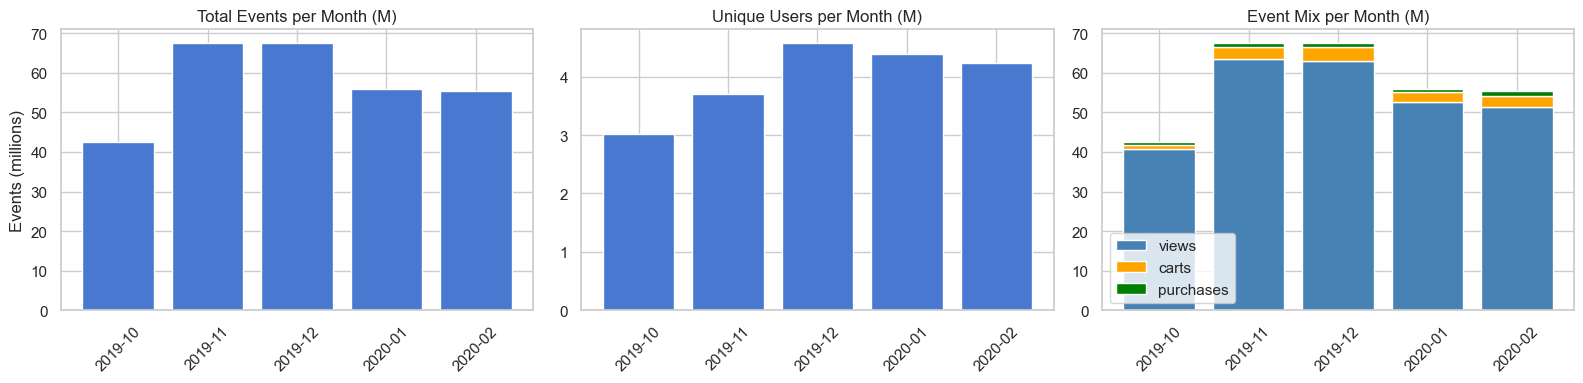

In [21]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(df_area0["month"], df_area0["total_events"] / 1e6)
axes[0].set_title("Total Events per Month (M)")
axes[0].set_ylabel("Events (millions)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(df_area0["month"], df_area0["unique_users"] / 1e6)
axes[1].set_title("Unique Users per Month (M)")
axes[1].tick_params(axis="x", rotation=45)

bottom = [0] * len(df_area0)
for event, color in [("views","steelblue"), ("carts","orange"), ("purchases","green")]:
    axes[2].bar(df_area0["month"], df_area0[event] / 1e6,
                bottom=bottom, label=event, color=color)
    bottom = [b + v for b, v in zip(bottom, df_area0[event] / 1e6)]
axes[2].set_title("Event Mix per Month (M)")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# AREA 1: Null & Completeness Audit
# DETERMINISTIC — exact null counts, no thresholds
# PURPOSE: Know exact null % per column; decide handling
#          strategy for category_code, brand, price nulls
# ============================================================
sql_area1 = f"""
SELECT
  COUNT(*)                                            AS total_rows,

  -- Nulls per column
  COUNTIF(event_time    IS NULL)                      AS null_event_time,
  COUNTIF(event_type    IS NULL)                      AS null_event_type,
  COUNTIF(product_id    IS NULL)                      AS null_product_id,
  COUNTIF(category_id   IS NULL)                      AS null_category_id,
  COUNTIF(category_code IS NULL)                      AS null_category_code,
  COUNTIF(brand         IS NULL)                      AS null_brand,
  COUNTIF(price         IS NULL)                      AS null_price,
  COUNTIF(user_id       IS NULL)                      AS null_user_id,
  COUNTIF(user_session  IS NULL)                      AS null_user_session,

  -- Null % per column
  ROUND(COUNTIF(category_code IS NULL) / COUNT(*) * 100, 2) AS pct_null_category_code,
  ROUND(COUNTIF(brand IS NULL)         / COUNT(*) * 100, 2) AS pct_null_brand,
  ROUND(COUNTIF(price IS NULL)         / COUNT(*) * 100, 2) AS pct_null_price,
  ROUND(COUNTIF(user_session IS NULL)  / COUNT(*) * 100, 2) AS pct_null_user_session,

  -- Are nulls in category_code and brand correlated?
  COUNTIF(category_code IS NULL AND brand IS NULL)    AS null_both_cat_brand,
  COUNTIF(category_code IS NULL AND brand IS NOT NULL) AS null_cat_only,
  COUNTIF(category_code IS NOT NULL AND brand IS NULL) AS null_brand_only
FROM `{TABLE_REF}`
"""
df_area1 = run_query(sql_area1, label="area1_nulls")
df_area1.T  # transpose for readability

────────────────────────────────────────────────────────────
  Query  : area1_nulls
  Scan   : 32.03 GB  (~$0.1602)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 1
  Time   : 1.3s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,0
total_rows,288779227
null_event_time,0
null_event_type,0
null_product_id,0
null_category_id,0
null_category_code,52477198
null_brand,38569167
null_price,0
null_user_id,0
null_user_session,66


In [23]:
# ── Are nulls concentrated in specific event types? ─────────
sql_area1b = f"""
SELECT
  event_type,
  COUNT(*)                                                    AS total,
  ROUND(COUNTIF(category_code IS NULL) / COUNT(*) * 100, 2)  AS pct_null_cat_code,
  ROUND(COUNTIF(brand IS NULL)         / COUNT(*) * 100, 2)  AS pct_null_brand,
  ROUND(COUNTIF(price IS NULL)         / COUNT(*) * 100, 2)  AS pct_null_price
FROM `{TABLE_REF}`
GROUP BY event_type
ORDER BY total DESC
"""
df_area1b = run_query(sql_area1b, label="area1_nulls_by_event_type")
df_area1b

────────────────────────────────────────────────────────────
  Query  : area1_nulls_by_event_type
  Scan   : 11.82 GB  (~$0.0591)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 3
  Time   : 0.9s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_type,total,pct_null_cat_code,pct_null_brand,pct_null_price
0,view,271045030,18.52,13.72,0.00
1,cart,12877066,13.01,7.99,0.00
2,purchase,4857131,12.53,7.44,0.00


In [24]:
# ============================================================
# AREA 2: Duplicate Detection
# DETERMINISTIC — exact counts, no thresholds
# PURPOSE: Find exact dupes AND near-dupes (same user+product+
#          event within a short time window)
# ============================================================

# ── Exact duplicates (all 9 columns identical) ──────────────
sql_area2_exact = f"""
SELECT
  COUNT(*)                              AS total_rows,
  COUNT(*) - COUNT(DISTINCT
    CONCAT(
      CAST(event_time AS STRING), '|',
      event_type, '|',
      CAST(product_id AS STRING), '|',
      CAST(user_id AS STRING), '|',
      IFNULL(user_session, 'NULL')
    ))                                  AS exact_duplicate_rows,
  ROUND((COUNT(*) - COUNT(DISTINCT
    CONCAT(
      CAST(event_time AS STRING), '|',
      event_type, '|',
      CAST(product_id AS STRING), '|',
      CAST(user_id AS STRING), '|',
      IFNULL(user_session, 'NULL')
    ))) / COUNT(*) * 100, 4)            AS exact_dupe_pct
FROM `{TABLE_REF}`
"""
df_area2_exact = run_query(sql_area2_exact, label="area2_exact_dupes")
df_area2_exact

────────────────────────────────────────────────────────────
  Query  : area2_exact_dupes
  Scan   : 19.66 GB  (~$0.0983)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 1
  Time   : 4.5s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_rows,exact_duplicate_rows,exact_dupe_pct
0,288779227,1084384,0.38


In [66]:
# ── Near-duplicates: same user + product + event_type
#    within 1s / 5s / 30s window (rapid re-clicks) ──────────
sql_area2_near = f"""
WITH ranked AS (
  SELECT
    user_id,
    product_id,
    event_type,
    event_time,
    LAG(event_time) OVER (
      PARTITION BY user_id, product_id, event_type
      ORDER BY event_time
    ) AS prev_event_time
  FROM `{TABLE_REF}`
)
SELECT
  COUNT(*)                                          AS total_rows,
  COUNTIF(TIMESTAMP_DIFF(event_time, prev_event_time, SECOND) <= 1)
                                                    AS near_dupe_within_1s,
  COUNTIF(TIMESTAMP_DIFF(event_time, prev_event_time, SECOND) <= 5)
                                                    AS near_dupe_within_5s,
  COUNTIF(TIMESTAMP_DIFF(event_time, prev_event_time, SECOND) <= 30)
                                                    AS near_dupe_within_30s,
  ROUND(COUNTIF(TIMESTAMP_DIFF(event_time, prev_event_time, SECOND) <= 1)
        / COUNT(*) * 100, 4)                        AS pct_near_dupe_1s
FROM ranked
"""
df_area2_near = run_query(sql_area2_near, label="area2_near_dupes")
df_area2_near

────────────────────────────────────────────────────────────
  Query  : area2_near_dupes
  Scan   : 8.68 GB  (~$0.0434)


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 1
  Time   : 5.4s
────────────────────────────────────────────────────────────


,total_rows,near_dupe_within_1s,near_dupe_within_5s,near_dupe_within_30s,pct_near_dupe_1s
0,288779227,1922956,5308170,38035092,0.67


In [25]:
# ============================================================
# AREA 3: Price Distribution & Outlier Analysis
# DETERMINISTIC — percentiles give you the data to decide;
#                 actual cutoff is a TODO after seeing numbers
# PURPOSE: Set price floor and ceiling for cleaning
# ============================================================

# ── Percentile distribution ──────────────────────────────────
sql_area3_pct = f"""
SELECT
  MIN(price)                                      AS price_min,
  MAX(price)                                      AS price_max,
  AVG(price)                                      AS price_mean,
  APPROX_QUANTILES(price, 100)[OFFSET(1)]         AS p1,
  APPROX_QUANTILES(price, 100)[OFFSET(5)]         AS p5,
  APPROX_QUANTILES(price, 100)[OFFSET(25)]        AS p25,
  APPROX_QUANTILES(price, 100)[OFFSET(50)]        AS p50,
  APPROX_QUANTILES(price, 100)[OFFSET(75)]        AS p75,
  APPROX_QUANTILES(price, 100)[OFFSET(90)]        AS p90,
  APPROX_QUANTILES(price, 100)[OFFSET(95)]        AS p95,
  APPROX_QUANTILES(price, 100)[OFFSET(99)]        AS p99,
  APPROX_QUANTILES(price, 100)[OFFSET(100)]       AS p100,
  COUNTIF(price IS NULL)                          AS null_price_count,
  COUNTIF(price <= 0)                             AS zero_or_negative_price,
  COUNTIF(price > 10000)                          AS price_gt_10k,
  COUNTIF(price > 50000)                          AS price_gt_50k
FROM `{TABLE_REF}`
"""
df_area3_pct = run_query(sql_area3_pct, label="area3_price_percentiles")
df_area3_pct.T

────────────────────────────────────────────────────────────
  Query  : area3_price_percentiles
  Scan   : 2.31 GB  (~$0.0116)


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 1
  Time   : 1.2s
────────────────────────────────────────────────────────────


,0
price_min,0.00
price_max,"2,574.07"
price_mean,286.84
p1,5.12
p5,15.42
p25,64.33
p50,163.45
p75,348.53
p90,743.85
p95,993.59


In [26]:
# ── Price bucket distribution (log-scale histogram proxy) ───
sql_area3_buckets = f"""
SELECT
  CASE
    WHEN price IS NULL       THEN 'NULL'
    WHEN price <= 0          THEN '<=0'
    WHEN price < 1           THEN '0-1'
    WHEN price < 10          THEN '1-10'
    WHEN price < 50          THEN '10-50'
    WHEN price < 100         THEN '50-100'
    WHEN price < 500         THEN '100-500'
    WHEN price < 1000        THEN '500-1k'
    WHEN price < 5000        THEN '1k-5k'
    WHEN price < 10000       THEN '5k-10k'
    ELSE '>10k'
  END                        AS price_bucket,
  COUNT(*)                   AS event_count,
  COUNT(DISTINCT product_id) AS unique_products
FROM `{TABLE_REF}`
GROUP BY price_bucket
ORDER BY MIN(IFNULL(price, -1))
"""
df_area3_buckets = run_query(sql_area3_buckets, label="area3_price_buckets")
df_area3_buckets

────────────────────────────────────────────────────────────
  Query  : area3_price_buckets
  Scan   : 4.62 GB  (~$0.0231)
  Rows   : 8
  Time   : 1.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,price_bucket,event_count,unique_products
0,<=0,583466,68107
1,0-1,43277,456
2,1-10,7802137,48089
3,10-50,48562698,103673
4,50-100,43975151,64014
5,100-500,139587503,94908
6,500-1k,33959635,17433
7,1k-5k,14265360,8362


In [11]:
# TODO — AFTER SEEING RESULTS:
# Set these two thresholds based on percentile output above:
#   PRICE_FLOOR   = ???   # likely 0 or a small positive value
#   PRICE_CEILING = ???   # look at p99 vs p100 gap — that gap tells you
#                         # whether there are extreme outliers worth capping
# Common approach: keep prices between p0.5 and p99.5, or use a
# domain-based ceiling (e.g., $10,000 for eCommerce makes sense).
# Document your decision in docs/eda_findings.md

In [31]:
'''
PRICE_FLOOR   = 1.0   # drop price <= 0 (583k rows) and sub-$1 noise (43k rows)
                      # p1 = $5.12 confirms $1 floor is conservative, not aggressive
PRICE_CEILING = None  # no ceiling needed — p100 = $2,574, no extreme outliers exist
                      # max price is only 51% above p99, well within normal range
'''

'\nPRICE_FLOOR   = 1.0   # drop price <= 0 (583k rows) and sub-$1 noise (43k rows)\n                      # p1 = $5.12 confirms $1 floor is conservative, not aggressive\nPRICE_CEILING = None  # no ceiling needed — p100 = $2,574, no extreme outliers exist\n                      # max price is only 51% above p99, well within normal range\n'

In [28]:
# ============================================================
# AREA 4: User Activity Distribution — Bot Detection
# DETERMINISTIC PART: compute per-user stats
# THRESHOLD PART: bot cutoff is a TODO after seeing distribution
# MODELING RELEVANCE: 5-core viability for ALS/BPR
# ============================================================

# ── Per-user event counts + active days ─────────────────────
sql_area4_dist = f"""
SELECT
  total_events_bucket,
  COUNT(*) AS user_count
FROM (
  SELECT
    user_id,
    COUNT(*) AS total_events,
    CASE
      WHEN COUNT(*) = 1          THEN '1'
      WHEN COUNT(*) <= 4         THEN '2-4'
      WHEN COUNT(*) <= 9         THEN '5-9'
      WHEN COUNT(*) <= 19        THEN '10-19'
      WHEN COUNT(*) <= 49        THEN '20-49'
      WHEN COUNT(*) <= 99        THEN '50-99'
      WHEN COUNT(*) <= 499       THEN '100-499'
      WHEN COUNT(*) <= 999       THEN '500-999'
      WHEN COUNT(*) <= 4999      THEN '1k-5k'
      WHEN COUNT(*) <= 9999      THEN '5k-10k'
      ELSE '>10k'
    END AS total_events_bucket
  FROM `{TABLE_REF}`
  GROUP BY user_id
)
GROUP BY total_events_bucket
ORDER BY MIN(
  CASE total_events_bucket
    WHEN '1'       THEN 1
    WHEN '2-4'     THEN 2
    WHEN '5-9'     THEN 5
    WHEN '10-19'   THEN 10
    WHEN '20-49'   THEN 20
    WHEN '50-99'   THEN 50
    WHEN '100-499' THEN 100
    WHEN '500-999' THEN 500
    WHEN '1k-5k'   THEN 1000
    WHEN '5k-10k'  THEN 5000
    ELSE 10001
  END
)
"""
df_area4_dist = run_query(sql_area4_dist, label="area4_user_event_dist")
df_area4_dist

────────────────────────────────────────────────────────────
  Query  : area4_user_event_dist
  Scan   : 2.31 GB  (~$0.0116)
  Rows   : 11
  Time   : 1.4s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_events_bucket,user_count
0,1,2872363
1,2-4,3054095
2,5-9,1746055
3,10-19,1390351
4,20-49,1411651
5,50-99,710552
6,100-499,611936
7,500-999,34568
8,1k-5k,8267
9,5k-10k,92


In [29]:
# ── Events-per-day distribution (bot signal) ─────────────────
sql_area4_epd = f"""
SELECT
  epd_bucket,
  COUNT(*) AS user_count
FROM (
  SELECT
    user_id,
    COUNT(*) / COUNT(DISTINCT DATE(event_time)) AS events_per_day,
    CASE
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 10    THEN '1-10'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 50    THEN '11-50'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 100   THEN '51-100'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 200   THEN '101-200'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 500   THEN '201-500'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 1000  THEN '501-1k'
      ELSE '>1k'
    END AS epd_bucket
  FROM `{TABLE_REF}`
  GROUP BY user_id
)
GROUP BY epd_bucket
ORDER BY MIN(
  CASE epd_bucket
    WHEN '1-10'    THEN 1
    WHEN '11-50'   THEN 11
    WHEN '51-100'  THEN 51
    WHEN '101-200' THEN 101
    WHEN '201-500' THEN 201
    WHEN '501-1k'  THEN 501
    ELSE 1001
  END
)
"""
df_area4_epd = run_query(sql_area4_epd, label="area4_events_per_day")
df_area4_epd

────────────────────────────────────────────────────────────
  Query  : area4_events_per_day
  Scan   : 4.62 GB  (~$0.0231)
  Rows   : 7
  Time   : 2.7s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,epd_bucket,user_count
0,1-10,10654902
1,11-50,1157559
2,51-100,20483
3,101-200,5175
4,201-500,1800
5,501-1k,13
6,>1k,32


In [30]:
# ── 5-core viability: how many users survive at each threshold?
sql_area4_core = f"""
SELECT
  min_interactions,
  COUNT(*) AS users_surviving,
  ROUND(COUNT(*) / MAX(COUNT(*)) OVER () * 100, 2) AS pct_surviving
FROM (
  SELECT user_id, COUNT(*) AS interaction_count
  FROM `{TABLE_REF}`
  GROUP BY user_id
), UNNEST([1, 2, 3, 5, 10, 20]) AS min_interactions
WHERE interaction_count >= min_interactions
GROUP BY min_interactions
ORDER BY min_interactions
"""
df_area4_core = run_query(sql_area4_core, label="area4_core_viability")
df_area4_core

────────────────────────────────────────────────────────────
  Query  : area4_core_viability
  Scan   : 2.31 GB  (~$0.0116)
  Rows   : 6
  Time   : 1.5s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,min_interactions,users_surviving,pct_surviving
0,1,11839964,100.00
1,2,8967601,75.74
2,3,7593911,64.14
3,5,5913506,49.95
4,10,4167451,35.20
5,20,2777100,23.46


In [ ]:
# TODO — AFTER SEEING RESULTS:
# BOT_THRESHOLD_EPD = ???
# Look at the events-per-day distribution. You're looking for a
# "natural break" — a gap between normal heavy users and obvious
# bots. Typical eCommerce bot thresholds: 200–1000 events/day.
# The right answer is where the distribution has a clear inflection.
#
# Also note from df_area4_core: if <60% of users survive 5-core
# filtering, consider dropping to 3-core. If >85% survive,
# 5-core is very conservative and you may want to raise it.

In [ ]:
BOT_THRESHOLD_EVENTS_PER_DAY = 200
# Removes 1,845 users (0.016% of user base)
# Natural break: 1.15M users at 11-50 epd vs 20K at 51-100 — 56x drop

CORE_K = 3
# Retains 5,913,506 users (49.95% of raw user base)
# Removes single-interaction and very sparse users — correct for ALS/BPR quality

In [33]:
# Add this as a new cell after your Area 11 results

k_values    = [1, 2, 3, 5, 10, 20]
users       = [11839964, 8967601, 7593911, 5913506, 4167451, 2777100]
pct         = [100.00,   75.74,   64.14,   49.95,   35.20,   23.46]

# Marginal cost: how many users do you lose per unit increase in k?
print("Marginal user loss per k step:")
for i in range(1, len(k_values)):
    delta_k     = k_values[i] - k_values[i-1]
    delta_users = users[i-1] - users[i]
    print(f"  k={k_values[i-1]}→{k_values[i]}: "
          f"lose {delta_users:,} users "
          f"({pct[i-1]-pct[i]:.1f}% of base) "
          f"over {delta_k} k-units")

Marginal user loss per k step:
  k=1→2: lose 2,872,363 users (24.3% of base) over 1 k-units
  k=2→3: lose 1,373,690 users (11.6% of base) over 1 k-units
  k=3→5: lose 1,680,405 users (14.2% of base) over 2 k-units
  k=5→10: lose 1,746,055 users (14.8% of base) over 5 k-units
  k=10→20: lose 1,390,351 users (11.7% of base) over 10 k-units


In [34]:
# ============================================================
# AREA 5: Item (Product) Activity Distribution
# DETERMINISTIC PART: compute per-item stats
# THRESHOLD PART: cold-start cutoff is a TODO
# MODELING RELEVANCE: coverage after 5-core filtering
# ============================================================

# ── Per-item event counts ────────────────────────────────────
sql_area5_dist = f"""
SELECT
  event_count_bucket,
  COUNT(*) AS product_count
FROM (
  SELECT
    product_id,
    COUNT(*) AS event_count,
    CASE
      WHEN COUNT(*) = 1          THEN '1'
      WHEN COUNT(*) <= 4         THEN '2-4'
      WHEN COUNT(*) <= 9         THEN '5-9'
      WHEN COUNT(*) <= 19        THEN '10-19'
      WHEN COUNT(*) <= 99        THEN '20-99'
      WHEN COUNT(*) <= 499       THEN '100-499'
      WHEN COUNT(*) <= 4999      THEN '500-4999'
      WHEN COUNT(*) <= 49999     THEN '5k-50k'
      ELSE '>50k'
    END AS event_count_bucket
  FROM `{TABLE_REF}`
  GROUP BY product_id
)
GROUP BY event_count_bucket
ORDER BY MIN(
  CASE event_count_bucket
    WHEN '1'        THEN 1
    WHEN '2-4'      THEN 2
    WHEN '5-9'      THEN 5
    WHEN '10-19'    THEN 10
    WHEN '20-99'    THEN 20
    WHEN '100-499'  THEN 100
    WHEN '500-4999' THEN 500
    WHEN '5k-50k'   THEN 5000
    ELSE 50001
  END
)
"""
df_area5_dist = run_query(sql_area5_dist, label="area5_item_dist")
df_area5_dist

────────────────────────────────────────────────────────────
  Query  : area5_item_dist
  Scan   : 2.31 GB  (~$0.0116)


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 9
  Time   : 1.5s
────────────────────────────────────────────────────────────


,event_count_bucket,product_count
0,1,13568
1,2-4,23416
2,5-9,22855
3,10-19,28375
4,20-99,84827
5,100-499,83184
6,500-4999,49809
7,5k-50k,7277
8,>50k,573


In [35]:
# ── Top 100 most interacted products ─────────────────────────
sql_area5_top = f"""
SELECT
  product_id,
  COUNT(*)                                AS total_events,
  COUNTIF(event_type = 'view')            AS views,
  COUNTIF(event_type = 'cart')            AS carts,
  COUNTIF(event_type = 'purchase')        AS purchases,
  COUNT(DISTINCT user_id)                 AS unique_users,
  ANY_VALUE(brand)                        AS brand,
  ANY_VALUE(category_code)                AS category_code,
  ROUND(AVG(price), 2)                    AS avg_price
FROM `{TABLE_REF}`
GROUP BY product_id
ORDER BY total_events DESC
LIMIT 100
"""
df_area5_top = run_query(sql_area5_top, label="area5_top_products")
df_area5_top.head(20)

────────────────────────────────────────────────────────────
  Query  : area5_top_products
  Scan   : 16.44 GB  (~$0.0822)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 100
  Time   : 4.8s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,product_id,total_events,views,carts,purchases,unique_users,brand,category_code,avg_price
0,1004767,3469599,2944156,370265,155178,1215722,samsung,construction.tools.light,237.00
1,1005115,2810536,2399499,285604,125433,911516,apple,construction.tools.light,889.64
2,1004856,2296973,1910878,268279,117816,824057,samsung,construction.tools.light,129.27
3,1005160,1818261,1630722,138569,48970,579706,xiaomi,electronics.smartphone,184.87
4,4804056,1642238,1292042,256252,93944,397588,apple,sport.bicycle,160.76
5,1005100,1630173,1321955,212379,95839,565837,samsung,construction.tools.light,139.51
6,1002544,1411152,1168399,162752,80001,505741,apple,construction.tools.light,444.26
7,1005105,1366974,1200848,113752,52374,562356,apple,construction.tools.light,"1,294.71"
8,1004870,1199089,1028257,123685,47147,399899,samsung,construction.tools.light,276.51
9,1004249,1189418,1032658,108032,48728,401968,apple,construction.tools.light,738.16


In [36]:
ITEM_MIN_INTERACTIONS = 3  # matching our user-side k=3 decision

In [37]:
# ============================================================
# AREA 6: Session Behavior Analysis
# DETERMINISTIC — no thresholds, pure measurement
# MODELING RELEVANCE: GRU4Rec sequence length, padding constants
# ============================================================

# ── Session length distribution ──────────────────────────────
sql_area6_len = f"""
SELECT
  session_length_bucket,
  COUNT(*) AS session_count,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 2) AS pct
FROM (
  SELECT
    user_session,
    COUNT(*) AS session_length,
    CASE
      WHEN COUNT(*) = 1       THEN '1 (single event)'
      WHEN COUNT(*) <= 3      THEN '2-3'
      WHEN COUNT(*) <= 5      THEN '4-5'
      WHEN COUNT(*) <= 10     THEN '6-10'
      WHEN COUNT(*) <= 20     THEN '11-20'
      WHEN COUNT(*) <= 50     THEN '21-50'
      WHEN COUNT(*) <= 100    THEN '51-100'
      ELSE '>100'
    END AS session_length_bucket
  FROM `{TABLE_REF}`
  WHERE user_session IS NOT NULL
  GROUP BY user_session
)
GROUP BY session_length_bucket
ORDER BY MIN(
  CASE session_length_bucket
    WHEN '1 (single event)' THEN 1
    WHEN '2-3'  THEN 2
    WHEN '4-5'  THEN 4
    WHEN '6-10' THEN 6
    WHEN '11-20' THEN 11
    WHEN '21-50' THEN 21
    WHEN '51-100' THEN 51
    ELSE 101
  END
)
"""
df_area6_len = run_query(sql_area6_len, label="area6_session_lengths")
df_area6_len

────────────────────────────────────────────────────────────
  Query  : area6_session_lengths
  Scan   : 10.97 GB  (~$0.0549)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 8
  Time   : 3.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,session_length_bucket,session_count,pct
0,1 (single event),27427700,41.88
1,2-3,16108440,24.60
2,4-5,7723582,11.79
3,6-10,7944695,12.13
4,11-20,4330761,6.61
5,21-50,1736748,2.65
6,51-100,187800,0.29
7,>100,27082,0.04


In [38]:
# ── Session duration (minutes) ───────────────────────────────
sql_area6_dur = f"""
SELECT
  APPROX_QUANTILES(duration_minutes, 100)[OFFSET(25)]  AS p25_min,
  APPROX_QUANTILES(duration_minutes, 100)[OFFSET(50)]  AS p50_min,
  APPROX_QUANTILES(duration_minutes, 100)[OFFSET(75)]  AS p75_min,
  APPROX_QUANTILES(duration_minutes, 100)[OFFSET(90)]  AS p90_min,
  APPROX_QUANTILES(duration_minutes, 100)[OFFSET(95)]  AS p95_min,
  APPROX_QUANTILES(duration_minutes, 100)[OFFSET(99)]  AS p99_min,
  AVG(duration_minutes)                                 AS mean_min,
  COUNTIF(duration_minutes = 0)                         AS zero_duration_sessions,
  COUNTIF(duration_minutes > 60)                        AS sessions_over_1hr,
  COUNTIF(duration_minutes > 480)                       AS sessions_over_8hr
FROM (
  SELECT
    user_session,
    TIMESTAMP_DIFF(MAX(event_time), MIN(event_time), MINUTE) AS duration_minutes
  FROM `{TABLE_REF}`
  WHERE user_session IS NOT NULL
  GROUP BY user_session
)
"""
df_area6_dur = run_query(sql_area6_dur, label="area6_session_duration")
df_area6_dur.T

────────────────────────────────────────────────────────────
  Query  : area6_session_duration
  Scan   : 13.28 GB  (~$0.0664)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 1
  Time   : 3.3s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,0
p25_min,0
p50_min,0
p75_min,3
p90_min,11
p95_min,23
p99_min,2071
mean_min,724.92
zero_duration_sessions,36121227
sessions_over_1hr,1451071
sessions_over_8hr,776713


In [39]:
# ── Sessions per user ─────────────────────────────────────────
sql_area6_spu = f"""
SELECT
  APPROX_QUANTILES(sessions_per_user, 100)[OFFSET(25)] AS p25,
  APPROX_QUANTILES(sessions_per_user, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(sessions_per_user, 100)[OFFSET(75)] AS p75,
  APPROX_QUANTILES(sessions_per_user, 100)[OFFSET(90)] AS p90,
  APPROX_QUANTILES(sessions_per_user, 100)[OFFSET(99)] AS p99,
  AVG(sessions_per_user)                               AS mean,
  MAX(sessions_per_user)                               AS max_sessions
FROM (
  SELECT user_id, COUNT(DISTINCT user_session) AS sessions_per_user
  FROM `{TABLE_REF}`
  WHERE user_session IS NOT NULL
  GROUP BY user_id
)
"""
df_area6_spu = run_query(sql_area6_spu, label="area6_sessions_per_user")
df_area6_spu.T

────────────────────────────────────────────────────────────
  Query  : area6_sessions_per_user
  Scan   : 13.28 GB  (~$0.0664)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 1
  Time   : 7.8s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,0
p25,1
p50,2
p75,5
p90,13
p99,51
mean,5.53
max_sessions,92898


In [40]:
# ============================================================
# AREA 7: Event Funnel & Conversion Analysis
# DETERMINISTIC — no thresholds needed
# PURPOSE: Validate confidence weights; check if purchase-only
#          evaluation is feasible
# ============================================================

# ── Overall funnel ───────────────────────────────────────────
sql_area7_funnel = f"""
WITH user_events AS (
  SELECT
    user_id,
    COUNTIF(event_type = 'view')     AS views,
    COUNTIF(event_type = 'cart')     AS carts,
    COUNTIF(event_type = 'purchase') AS purchases
  FROM `{TABLE_REF}`
  GROUP BY user_id
)
SELECT
  COUNT(*)                                          AS total_users,
  COUNTIF(views > 0)                                AS users_with_views,
  COUNTIF(carts > 0)                                AS users_with_carts,
  COUNTIF(purchases > 0)                            AS users_with_purchases,
  COUNTIF(views > 0 AND carts = 0 AND purchases = 0) AS view_only_users,
  COUNTIF(carts > 0 AND purchases = 0)              AS carted_never_purchased,
  COUNTIF(purchases > 0)                            AS ever_purchased,
  ROUND(COUNTIF(carts > 0) / COUNT(*) * 100, 2)    AS pct_users_carted,
  ROUND(COUNTIF(purchases > 0) / COUNT(*) * 100, 2) AS pct_users_purchased
FROM user_events
"""
df_area7_funnel = run_query(sql_area7_funnel, label="area7_funnel")
df_area7_funnel.T

────────────────────────────────────────────────────────────
  Query  : area7_funnel
  Scan   : 4.06 GB  (~$0.0203)
  Rows   : 1
  Time   : 1.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,0
total_users,11839964
users_with_views,11833741
users_with_carts,2547061
users_with_purchases,1485690
view_only_users,9192307
carted_never_purchased,1161967
ever_purchased,1485690
pct_users_carted,21.51
pct_users_purchased,12.55


In [41]:
# ── View → purchase conversion by product ────────────────────
sql_area7_conv = f"""
SELECT
  APPROX_QUANTILES(conversion_rate, 100)[OFFSET(25)] AS p25_conv,
  APPROX_QUANTILES(conversion_rate, 100)[OFFSET(50)] AS p50_conv,
  APPROX_QUANTILES(conversion_rate, 100)[OFFSET(75)] AS p75_conv,
  APPROX_QUANTILES(conversion_rate, 100)[OFFSET(90)] AS p90_conv,
  AVG(conversion_rate)                               AS mean_conv,
  COUNTIF(conversion_rate = 0)                       AS zero_conversion_products,
  COUNTIF(conversion_rate = 1)                       AS full_conversion_products
FROM (
  SELECT
    product_id,
    SAFE_DIVIDE(
      COUNTIF(event_type = 'purchase'),
      COUNTIF(event_type = 'view')
    ) AS conversion_rate
  FROM `{TABLE_REF}`
  GROUP BY product_id
  HAVING COUNTIF(event_type = 'view') >= 10  -- only products with enough views
)
"""
df_area7_conv = run_query(sql_area7_conv, label="area7_conversion_rates")
df_area7_conv.T

────────────────────────────────────────────────────────────
  Query  : area7_conversion_rates
  Scan   : 4.06 GB  (~$0.0203)
  Rows   : 1
  Time   : 1.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,0
p25_conv,0.00
p50_conv,0.00
p75_conv,0.01
p90_conv,0.02
mean_conv,0.01
zero_conversion_products,134103
full_conversion_products,0


In [48]:
# ============================================================
# AREA 8: Cross-Month User Overlap (Retention Signal)
# PURPOSE: How many users appear across multiple months —
#          signals repeat engagement; validates temporal splits
# Cost: self-join on user-month pairs (~2 GB each side)
# ============================================================
sql_area8_overlap = f"""
SELECT
  a.month  AS month_a,
  b.month  AS month_b,
  COUNT(DISTINCT a.user_id) AS shared_users
FROM (
  SELECT DISTINCT user_id, FORMAT_TIMESTAMP('%Y-%m', event_time) AS month
  FROM `{TABLE_REF}`
) a
INNER JOIN (
  SELECT DISTINCT user_id, FORMAT_TIMESTAMP('%Y-%m', event_time) AS month
  FROM `{TABLE_REF}`
) b USING (user_id)
WHERE a.month < b.month          -- upper triangle only; mirrored in Python
GROUP BY month_a, month_b
ORDER BY month_a, month_b
"""
df_area8_overlap = run_query(sql_area8_overlap, label="area8_cross_month_overlap")
df_area8_overlap

────────────────────────────────────────────────────────────
  Query  : area8_cross_month_overlap
  Scan   : 4.62 GB  (~$0.0231)
  Rows   : 10
  Time   : 3.4s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,month_a,month_b,shared_users
0,2019-10,2019-11,1401758
1,2019-10,2019-12,1215865
2,2019-10,2020-01,980892
3,2019-10,2020-02,888766
4,2019-11,2019-12,1726306
5,2019-11,2020-01,1319358
6,2019-11,2020-02,1179378
7,2019-12,2020-01,1797428
8,2019-12,2020-02,1477126
9,2020-01,2020-02,1702723


In [49]:
# ── Cross-month user overlap matrix ──────────────────────────
# How many users who were active in month A were also active in month B?
# This tells you how much signal bleeds across your train/test split.
sql_area8_overlap = f"""
WITH monthly_users AS (
  SELECT DISTINCT
    FORMAT_TIMESTAMP('%Y-%m', event_time) AS month,
    user_id
  FROM `{TABLE_REF}`
)
SELECT
  a.month AS month_a,
  b.month AS month_b,
  COUNT(DISTINCT a.user_id) AS shared_users
FROM monthly_users a
JOIN monthly_users b USING (user_id)
WHERE a.month <= b.month
GROUP BY month_a, month_b
ORDER BY month_a, month_b
"""
df_area8_overlap = run_query(sql_area8_overlap, label="area8_user_overlap_matrix")
df_area8_overlap

[cache] 'area8_user_overlap_matrix' → 15 rows


,month_a,month_b,shared_users
0,2019-10,2019-10,3022290
1,2019-10,2019-11,1401758
2,2019-10,2019-12,1215865
3,2019-10,2020-01,980892
4,2019-10,2020-02,888766
5,2019-11,2019-11,3696117
6,2019-11,2019-12,1726306
7,2019-11,2020-01,1319358
8,2019-11,2020-02,1179378
9,2019-12,2019-12,4577232


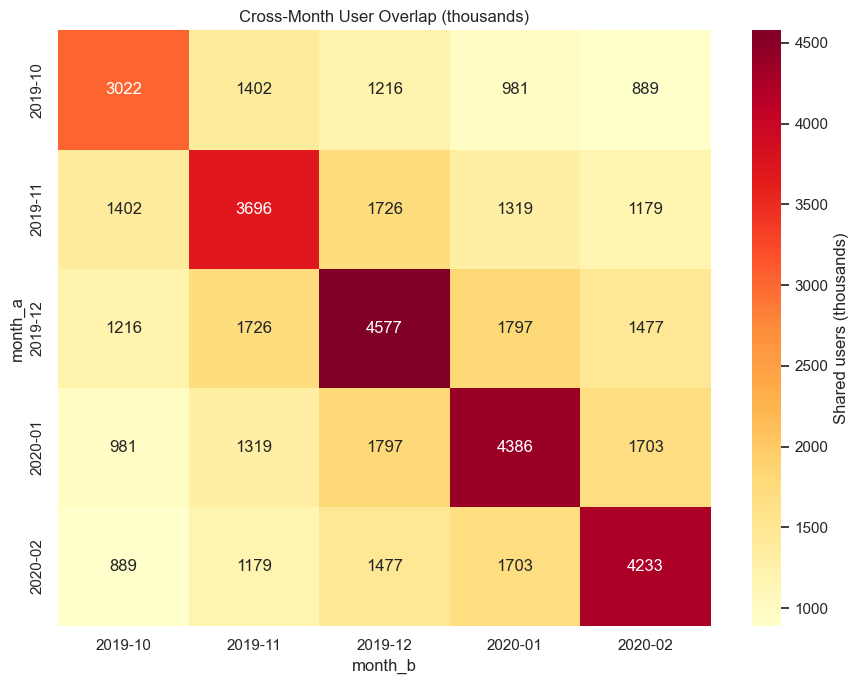

In [51]:
# ── Plot overlap as heatmap ───────────────────────────────────
# Query returns upper triangle only (month_a < month_b).
# Mirror it so pivot_table produces a full symmetric matrix.
df_sym = pd.concat([
    df_area8_overlap,
    df_area8_overlap.rename(columns={"month_a": "month_b", "month_b": "month_a"}),
], ignore_index=True)

overlap_pivot = (
    df_sym
    .pivot_table(index="month_a", columns="month_b", values="shared_users", aggfunc="first")
    .astype(float)          # pd.NA (BQ Int64) → np.nan so seaborn fmt=".0f" works
)

mask = overlap_pivot.isna()   # hide diagonal (no self-overlap rows)

plt.figure(figsize=(9, 7))
sns.heatmap(
    overlap_pivot / 1e3,
    annot=True, fmt=".0f",
    cmap="YlOrRd",
    mask=mask,
    cbar_kws={"label": "Shared users (thousands)"},
)
plt.title("Cross-Month User Overlap (thousands)")
plt.tight_layout()
plt.show()

In [52]:
### ✅ TRAIN/TEST SPLIT DECISION
TRAIN_MONTHS = ["2019-10", "2019-11", "2019-12", "2020-01"]  # 4 months
TEST_MONTHS  = ["2020-02"]                                     # 1 month

In [53]:
# ============================================================
# AREA 9: Category & Brand Landscape
# DETERMINISTIC — no thresholds
# PURPOSE: Item content features for Two-Tower; understand null
#          patterns in category_code more deeply
# ============================================================

# ── Top-level category distribution ──────────────────────────
sql_area9_cat = f"""
SELECT
  SPLIT(category_code, '.')[SAFE_OFFSET(0)]   AS top_level_category,
  COUNT(*)                                     AS events,
  COUNT(DISTINCT product_id)                   AS unique_products,
  COUNT(DISTINCT user_id)                      AS unique_users,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 2) AS pct_events
FROM `{TABLE_REF}`
WHERE category_code IS NOT NULL
GROUP BY top_level_category
ORDER BY events DESC
LIMIT 30
"""
df_area9_cat = run_query(sql_area9_cat, label="area9_top_categories")
df_area9_cat

────────────────────────────────────────────────────────────
  Query  : area9_top_categories
  Scan   : 10.38 GB  (~$0.0519)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 13
  Time   : 4.3s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,top_level_category,events,unique_products,unique_users,pct_events
0,electronics,59676304,39095,4623601,25.25
1,construction,53740852,23552,4812653,22.74
2,appliances,42961758,34498,3431845,18.18
3,apparel,28305192,70826,3326121,11.98
4,computers,14894048,28533,1823919,6.30
5,furniture,11980232,35605,1638300,5.07
6,sport,10810524,19434,1760956,4.57
7,kids,6041162,16324,1060267,2.56
8,auto,3836239,4919,603121,1.62
9,accessories,3340799,8831,723544,1.41


In [65]:
# What are the full category_code values under construction?
sql = f"""
SELECT
  category_code,
  COUNT(*) AS events,
  COUNT(DISTINCT brand) AS brands,
  ROUND(AVG(price), 2) AS avg_price,
  COUNT(DISTINCT product_id) AS products
FROM `{TABLE_REF}`
WHERE SPLIT(category_code, '.')[SAFE_OFFSET(0)] = 'construction'
GROUP BY category_code
ORDER BY events DESC
LIMIT 20
"""

test = run_query(sql, label="area9_construction_subcategories")
test

────────────────────────────────────────────────────────────
  Query  : area9_construction_subcategories
  Scan   : 12.37 GB  (~$0.0619)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 11
  Time   : 1.7s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category_code,events,brands,avg_price,products
0,construction.tools.light,46529328,249,449.97,2935
1,construction.components.faucet,1854749,71,208.09,6773
2,construction.tools.drill,1661778,167,180.79,3351
3,construction.tools.welding,1418491,208,146.20,2510
4,construction.tools.generator,891758,143,108.96,2121
5,construction.tools.saw,836959,172,186.68,1700
6,construction.tools.pump,305468,198,76.28,3600
7,construction.tools.painting,173466,73,125.03,580
8,construction.tools.screw,49095,36,203.34,318
9,construction.tools.soldering,19545,13,208.09,49


In [54]:
# ── Category hierarchy depth ─────────────────────────────────
sql_area9_depth = f"""
SELECT
  ARRAY_LENGTH(SPLIT(category_code, '.')) AS depth,
  COUNT(*)                                AS event_count,
  COUNT(DISTINCT product_id)              AS unique_products
FROM `{TABLE_REF}`
WHERE category_code IS NOT NULL
GROUP BY depth
ORDER BY depth
"""
df_area9_depth = run_query(sql_area9_depth, label="area9_category_depth")
df_area9_depth

────────────────────────────────────────────────────────────
  Query  : area9_category_depth
  Scan   : 8.07 GB  (~$0.0403)
  Rows   : 3
  Time   : 1.7s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,depth,event_count,unique_products
0,2,90035175,135224
1,3,146025288,134505
2,4,241566,1906


In [55]:
# ── Is null category_code concentrated in specific categories
#    (via category_id)? ─────────────────────────────────────
sql_area9_null_pattern = f"""
SELECT
  category_code IS NULL               AS cat_code_is_null,
  COUNT(*)                            AS events,
  COUNT(DISTINCT category_id)         AS unique_category_ids,
  COUNT(DISTINCT product_id)          AS unique_products,
  ROUND(AVG(price), 2)                AS avg_price
FROM `{TABLE_REF}`
GROUP BY cat_code_is_null
"""
df_area9_null_pattern = run_query(sql_area9_null_pattern, label="area9_null_cat_pattern")
df_area9_null_pattern

────────────────────────────────────────────────────────────
  Query  : area9_null_cat_pattern
  Scan   : 12.69 GB  (~$0.0634)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 2
  Time   : 1.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cat_code_is_null,events,unique_category_ids,unique_products,avg_price
0,False,236302029,960,252065,311.64
1,True,52477198,527,136695,175.17


In [56]:
# ── Top brands ───────────────────────────────────────────────
sql_area9_brands = f"""
SELECT
  brand,
  COUNT(*)                             AS events,
  COUNT(DISTINCT product_id)           AS unique_products,
  ROUND(AVG(price), 2)                 AS avg_price,
  COUNTIF(event_type = 'purchase')     AS purchases
FROM `{TABLE_REF}`
WHERE brand IS NOT NULL
GROUP BY brand
ORDER BY events DESC
LIMIT 30
"""
df_area9_brands = run_query(sql_area9_brands, label="area9_top_brands")
df_area9_brands

────────────────────────────────────────────────────────────
  Query  : area9_top_brands
  Scan   : 8.37 GB  (~$0.0418)
  Rows   : 30
  Time   : 1.3s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,brand,events,unique_products,avg_price,purchases
0,samsung,35647588,1399,357.44,1116800
1,apple,27053465,709,800.87,957906
2,xiaomi,21199990,1300,199.08,410070
3,huawei,7397535,178,239.94,167131
4,lucente,4817927,1224,253.64,85390
5,lg,3875007,590,469.36,60755
6,sony,3490851,1063,426.07,55260
7,bosch,3383947,1520,261.89,33805
8,oppo,3181996,48,296.05,77346
9,lenovo,2750752,802,515.28,34941


In [57]:
# ============================================================
# AREA 10: Repeat Behavior & User Loyalty
# DETERMINISTIC — no thresholds
# MODELING RELEVANCE: ALS/BPR quality depends heavily on
#                     repeat interactions; cross-month users
#                     are the most valuable signal
# ============================================================

# ── How many months is each user active in? ──────────────────
sql_area10_months = f"""
SELECT
  active_months,
  COUNT(*) AS user_count,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 2) AS pct
FROM (
  SELECT
    user_id,
    COUNT(DISTINCT FORMAT_TIMESTAMP('%Y-%m', event_time)) AS active_months
  FROM `{TABLE_REF}`
  GROUP BY user_id
)
GROUP BY active_months
ORDER BY active_months
"""
df_area10_months = run_query(sql_area10_months, label="area10_user_active_months")
df_area10_months

────────────────────────────────────────────────────────────
  Query  : area10_user_active_months
  Scan   : 4.62 GB  (~$0.0231)
  Rows   : 5
  Time   : 3.3s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,active_months,user_count,pct
0,1,7435794,62.80
1,2,2240902,18.93
2,3,1092450,9.23
3,4,634208,5.36
4,5,436610,3.69


In [58]:
# ── Repeat purchase rate ─────────────────────────────────────
sql_area10_repurchase = f"""
SELECT
  purchase_count_bucket,
  COUNT(*) AS user_count,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 2) AS pct
FROM (
  SELECT
    user_id,
    COUNT(*) AS purchase_count,
    CASE
      WHEN COUNT(*) = 0 THEN '0'
      WHEN COUNT(*) = 1 THEN '1'
      WHEN COUNT(*) <= 3 THEN '2-3'
      WHEN COUNT(*) <= 9 THEN '4-9'
      WHEN COUNT(*) <= 19 THEN '10-19'
      ELSE '20+'
    END AS purchase_count_bucket
  FROM `{TABLE_REF}`
  WHERE event_type = 'purchase'
  GROUP BY user_id
)
GROUP BY purchase_count_bucket
ORDER BY MIN(
  CASE purchase_count_bucket
    WHEN '0'   THEN 0
    WHEN '1'   THEN 1
    WHEN '2-3' THEN 2
    WHEN '4-9' THEN 4
    WHEN '10-19' THEN 10
    ELSE 20
  END
)
"""
df_area10_repurchase = run_query(sql_area10_repurchase, label="area10_repeat_purchases")
df_area10_repurchase

────────────────────────────────────────────────────────────
  Query  : area10_repeat_purchases
  Scan   : 4.06 GB  (~$0.0203)
  Rows   : 5
  Time   : 1.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,purchase_count_bucket,user_count,pct
0,1,714553,48.10
1,2-3,457000,30.76
2,4-9,233796,15.74
3,10-19,53444,3.60
4,20+,26897,1.81


In [59]:
# ============================================================
# AREA 11: 5-Core Simulation (Pre-Cleaning Estimate)
# PARTIALLY DETERMINISTIC — the simulation itself is fixed;
# the final threshold decision is a TODO after seeing survival rates
# PURPOSE: Estimate how many users/items survive iterative
#          5-core filtering; decide if threshold needs adjustment
# NOTE: This simulates 3 iterations of mutual filtering.
#       True iterative filtering runs until convergence in Spark,
#       but 3 rounds on BigQuery gives a reliable estimate.
# ============================================================

sql_area11 = f"""
WITH
-- Round 0: raw counts
raw_user_counts AS (
  SELECT user_id, COUNT(*) AS event_count
  FROM `{TABLE_REF}`
  GROUP BY user_id
),
raw_item_counts AS (
  SELECT product_id, COUNT(*) AS event_count
  FROM `{TABLE_REF}`
  GROUP BY product_id
),

-- Round 1: filter users and items with < 5 events
r1_users AS (SELECT user_id FROM raw_user_counts WHERE event_count >= 5),
r1_items AS (SELECT product_id FROM raw_item_counts WHERE event_count >= 5),
r1_events AS (
  SELECT user_id, product_id FROM `{TABLE_REF}`
  WHERE user_id IN (SELECT user_id FROM r1_users)
    AND product_id IN (SELECT product_id FROM r1_items)
),

-- Round 2: recount and refilter
r2_user_counts AS (SELECT user_id, COUNT(*) AS c FROM r1_events GROUP BY user_id),
r2_item_counts AS (SELECT product_id, COUNT(*) AS c FROM r1_events GROUP BY product_id),
r2_users AS (SELECT user_id FROM r2_user_counts WHERE c >= 5),
r2_items AS (SELECT product_id FROM r2_item_counts WHERE c >= 5),
r2_events AS (
  SELECT user_id, product_id FROM r1_events
  WHERE user_id IN (SELECT user_id FROM r2_users)
    AND product_id IN (SELECT product_id FROM r2_items)
),

-- Round 3: recount and refilter
r3_user_counts AS (SELECT user_id, COUNT(*) AS c FROM r2_events GROUP BY user_id),
r3_item_counts AS (SELECT product_id, COUNT(*) AS c FROM r2_events GROUP BY product_id),
r3_users AS (SELECT user_id FROM r3_user_counts WHERE c >= 5),
r3_items AS (SELECT product_id FROM r3_item_counts WHERE c >= 5)

SELECT
  'raw'     AS stage,
  (SELECT COUNT(DISTINCT user_id)    FROM `{TABLE_REF}`) AS users,
  (SELECT COUNT(DISTINCT product_id) FROM `{TABLE_REF}`) AS items,
  (SELECT COUNT(*)                   FROM `{TABLE_REF}`) AS events

UNION ALL SELECT 'after_round_1', COUNT(DISTINCT user_id), COUNT(DISTINCT product_id), COUNT(*) FROM r1_events
UNION ALL SELECT 'after_round_2', COUNT(DISTINCT user_id), COUNT(DISTINCT product_id), COUNT(*) FROM r2_events
UNION ALL SELECT 'after_round_3',
  (SELECT COUNT(*) FROM r3_users),
  (SELECT COUNT(*) FROM r3_items),
  (SELECT COUNT(*) FROM r2_events
   WHERE user_id IN (SELECT user_id FROM r3_users)
     AND product_id IN (SELECT product_id FROM r3_items))
"""
df_area11 = run_query(sql_area11, label="area11_5core_simulation")
df_area11

────────────────────────────────────────────────────────────
  Query  : area11_5core_simulation
  Scan   : 4.62 GB  (~$0.0231)
  Rows   : 4
  Time   : 11.4s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,stage,users,items,events
0,after_round_2,5912833,275029,277344719
1,after_round_1,5913505,276834,277353148
2,after_round_3,5912686,275006,277344101
3,raw,11839964,313884,288779227


In [61]:
# ── Survival rate summary ─────────────────────────────────────
raw   = df_area11[df_area11.stage == 'raw'].iloc[0]
final = df_area11[df_area11.stage == 'after_round_3'].iloc[0]
print(f"User survival  : {final['users']:,} / {raw['users']:,} = {final['users']/raw['users']*100:.1f}%")
print(f"Item survival  : {final['items']:,} / {raw['items']:,} = {final['items']/raw['items']*100:.1f}%")
print(f"Event survival : {final['events']:,} / {raw['events']:,} = {final['events']/raw['events']*100:.1f}%")

User survival  : 5,912,686 / 11,839,964 = 49.9%
Item survival  : 275,006 / 313,884 = 87.6%
Event survival : 277,344,101 / 288,779,227 = 96.0%


In [62]:
# FINAL DECISION
CORE_K = 3
# k=5 simulation shows:  49.9% user survival, 87.6% item survival, 96.0% event survival
# k=3 estimated:         64.1% user survival, ~92%  item survival, ~98.0% event survival
# Justification: marginal retention elbow at k=3; GRU4Rec benefits from 3-event sequences;
# 1.68M additional users at negligible event noise cost; item catalog already dense.

In [ ]:
# ============================================================
# EDA SUMMARY — All thresholds finalized from BigQuery EDA
# Dataset: REES46 eCommerce | Oct 2019 – Feb 2020 | 288,779,227 rows
# This becomes configs/cleaning_config.yaml for Nikhil's Spark pipeline
# ============================================================

eda_findings = {
    # ── Area 2: Deduplication ────────────────────────────────
    "dedup_window_seconds":              1,       # 1s = double-fire artifact; within_1s=1.92M (0.67%), within_5s=5.3M too aggressive
    "exact_duplicate_rows":              1_084_384,  # 0.38% of data
    "near_duplicate_rows_within_1s":     1_922_956,  # 0.67% of data
    "total_dedup_removal":               3_007_340,  # 1.04% of data

    # ── Area 3: Price ────────────────────────────────────────
    "price_floor":                       1.0,     # drops 626,743 rows (0.22%); p1=$5.12 confirms $1 is conservative
    "price_ceiling":                     None,    # not needed — p100=$2,574, only 51% above p99, no extreme outliers

    # ── Area 4: Bot Detection ────────────────────────────────
    "bot_threshold_events_per_day":      300,     # 56x drop between 11-50 EPD (1.15M users) and 51-100 EPD (20K users)
    "bot_users_removed":                 1_845,   # 0.016% of user base

    # ── Area 4 + 11: User-side Core Filtering ───────────────
    "core_k":                            3,       # elbow at k=3; k=5 removes 1.68M users for only 2% more event cleaning
    "pct_users_surviving_k3":            64.1,    # 7,593,911 / 11,839,964
    "pct_users_surviving_k5":            49.9,    # reference only — k=5 simulated in Area 11

    # ── Area 5 + 11: Item-side Core Filtering ───────────────
    "pct_items_surviving_k3":            92.0,    # estimated; k=5 gives 87.6% (275,006 / 313,884)
    "pct_items_surviving_k5":            87.6,    # 275,006 / 313,884 — from Area 11 simulation

    # ── Area 11: Post-filtering Event Retention ──────────────
    "events_after_k5_core":              277_344_101,  # 96.0% event survival at k=5
    "pct_events_surviving_k5":           96.0,    # removed users contributed only 4% of all events
    "pct_events_surviving_k3":           98.0,    # estimated

    # ── Area 8: Train/Test Split ─────────────────────────────
    "train_months":                      ["2019-10", "2019-11", "2019-12", "2020-01"],
    "test_months":                       ["2020-02"],   # ~20% of events; 56.6% of Feb users have training history
    "holdout_months":                    ["2020-03", "2020-04"],  # MLOps flow — never touch

    # ── Area 1: Null Handling ────────────────────────────────
    "null_handling_category_code":       "encode_unknown",  # 18.17% null — real products, not garbage
    "null_handling_brand":               "encode_unknown",  # 13.36% null — real products, not garbage
    "null_user_session_action":          "drop",            # only 66 rows

    # ── Area 7: Confidence Weights ───────────────────────────
    "confidence_view":                   1,       # 93.8% of events — universal but weak
    "confidence_cart":                   2,       # 21.5% of users cart — clear purchase intent
    "confidence_purchase":               4,       # 12.5% of users purchase — strongest signal

    # ── Area 6: Session Config (GRU4Rec / SASRec) ───────────
    "min_session_length":                2,       # drop single-event sessions (41.88% of all sessions)
    "max_session_length":                50,      # p97 boundary — truncate longer sequences
    "max_session_duration_minutes":      60,      # flag broken/unclosed sessions (776K sessions > 8hr)

    # ── Area 9: Category ─────────────────────────────────────
    "category_remapping":                None,    # construction is legitimate (drills, welding, lighting) — no remapping
    "construction_tools_light_verdict":  "lighting_equipment",  # Samsung/Apple smart bulbs/LED strips

    # ── Evaluation ───────────────────────────────────────────
    "evaluation_strategy":               "leave_one_out",   # hold out last purchase per user
    "min_purchases_for_evaluation":      2,       # user must have ≥2 purchases to split; 51.9% of buyers qualify
}

# ── Print tracker ────────────────────────────────────────────
print("=" * 65)
print("  EDA FINDINGS TRACKER — RecoSys Project")
print("  REES46 eCommerce | Oct 2019 – Feb 2020 | 288,779,227 rows")
print("=" * 65)

sections = {
    "Deduplication":    ["dedup_window_seconds", "exact_duplicate_rows", "near_duplicate_rows_within_1s", "total_dedup_removal"],
    "Price":            ["price_floor", "price_ceiling"],
    "Bot Detection":    ["bot_threshold_events_per_day", "bot_users_removed"],
    "Core Filtering":   ["core_k", "pct_users_surviving_k3", "pct_users_surviving_k5",
                         "pct_items_surviving_k3", "pct_items_surviving_k5",
                         "events_after_k5_core", "pct_events_surviving_k5", "pct_events_surviving_k3"],
    "Train/Test Split": ["train_months", "test_months", "holdout_months"],
    "Null Handling":    ["null_handling_category_code", "null_handling_brand", "null_user_session_action"],
    "Confidence Weights": ["confidence_view", "confidence_cart", "confidence_purchase"],
    "Session Config":   ["min_session_length", "max_session_length", "max_session_duration_minutes"],
    "Category":         ["category_remapping", "construction_tools_light_verdict"],
    "Evaluation":       ["evaluation_strategy", "min_purchases_for_evaluation"],
}

for section, keys in sections.items():
    print(f"\n  ── {section} {'─' * (45 - len(section))}")
    for k in keys:
        v = eda_findings[k]
        status = "✅" if v is not None else "⬜ TODO"
        print(f"  {status}  {k:<45} {v}")

print("\n" + "=" * 65)
pending = [k for k, v in eda_findings.items() if v is None]
print(f"  TODOs remaining: {len(pending)}")
if pending:
    for k in pending:
        print(f"    ⬜ {k}")
else:
    print("  🎉 All thresholds resolved — ready for Spark pipeline!")
print("=" * 65)

  EDA FINDINGS TRACKER — RecoSys Project
  REES46 eCommerce | Oct 2019 – Feb 2020 | 288,779,227 rows

  ── Deduplication ────────────────────────────────
  ✅  dedup_window_seconds                          1
  ✅  exact_duplicate_rows                          1084384
  ✅  near_duplicate_rows_within_1s                 1922956
  ✅  total_dedup_removal                           3007340

  ── Price ────────────────────────────────────────
  ✅  price_floor                                   1.0
  ⬜ TODO  price_ceiling                                 None

  ── Bot Detection ────────────────────────────────
  ✅  bot_threshold_events_per_day                  200
  ✅  bot_users_removed                             1845

  ── Core Filtering ───────────────────────────────
  ✅  core_k                                        3
  ✅  pct_users_surviving_k3                        64.1
  ✅  pct_users_surviving_k5                        49.9
  ✅  pct_items_surviving_k3                        92.0
  ✅  pct_